### Lab IV: Linear Models
### Answer all three sets of questions

# Question 0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
3. Can linear regression be used for classification? Explain why, or why not.
4. If you have a high accuracy on testing but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

### Answers

1. What makes a model linear is the parameters created by the model, the betas. It weighs the variables together and gives a predicted value, assigning different weights to different variables. The thing that is linear is the coefficients, not necessarily the x's because those can be squared, logged, etc. The betas are purely just multipliers regardless of what you do to the x variables.
2. You interpret the coefficient for a dummy variable as the mean value of the y variable for each category of that encoded variable IF THERE IS NO INTERCEPT. If there IS an intercept, then the intercept for the dropped/reference group of the variable (the one that will be all 0s) will be that group's mean of the y variable, and the other categories will be the *difference* of the mean of that new category from the reference category's mean.
3. Linear regression can kind of be used for classification if you use it to predict an output value that is then subject to a cutoff value, but it's not directly capable of classification. They are also difficult to interpret in terms of probability if you have it predict a number since it's on a continuous scale that will go outside the bounds of 0 to 1, making it an invalid probability.
4. (I assume this is a typo, so I'll just answer both variants) If you have a high accuracy on training, but low on testing, the model is likely overfit to the training data and is not actually learning the patterns. With high accuracy on testing, but low on training, there may be some sort of data leakage in the test set.
5. Two ways to incorporate nonlinear relationships between y and x are logging certain features or squaring them. You can also put them to other powers like cubed and square root, depending on what makes it capture the relationship (feature engineering). You are also able to use bins to cut the continuous variable into intervals and then make a regression line for each section rather than the whole thing all at once.
6. The interpretation of the intercept is the predicted value of y when all x variables are 0. A slope coefficient for a variable is the average change in y given a one unit change in that slope, given all other variables are constant. The interpretation of the coefficient of a one-hot encoded variable is, with an intercept, the average difference in y from the reference group for that given group. Without an intercept, the coefficient is the average of that given group's value of the y variable.

# Question 1

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv')
df = df.rename(columns = {'Neighbourhood ': 'Neighborhood'}) # There is a space at the end of the column name, and I changed the spelling to the American version of the word as well
df.head()

,Price,Review Scores Rating,Neighborhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


### Q1.1

In [2]:
# Compute average prices and scores by Neighborhood

df.groupby('Neighborhood')[['Price', 'Review Scores Rating']].mean()

,Price,Review Scores Rating
Neighborhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive on average, sitting around $183.66.

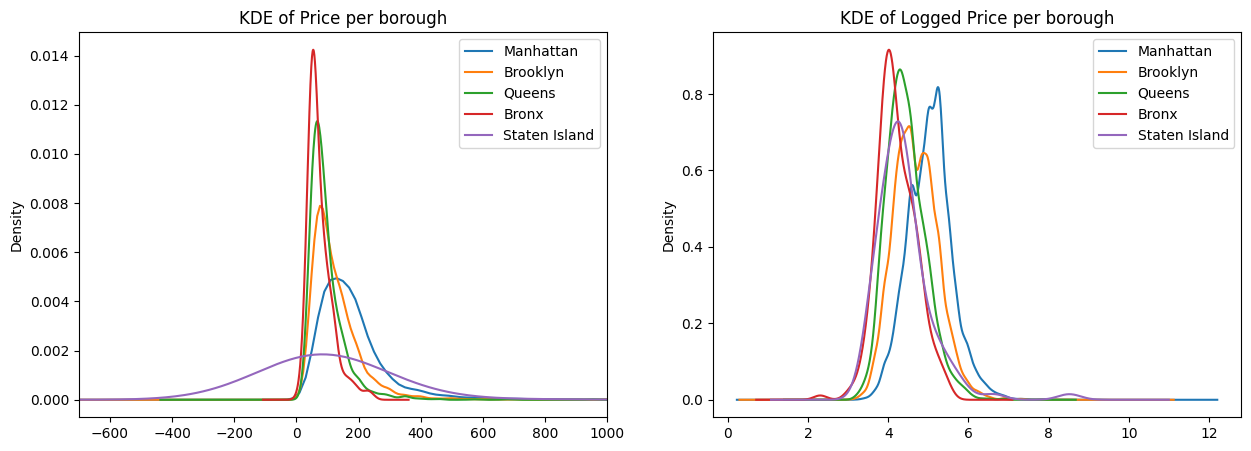

In [3]:
# KDE Plot of Price and log Price

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

for neighborhood in df['Neighborhood'].unique():
    subset = df[df['Neighborhood'] == neighborhood]
    subset['Price'].plot.kde(ax = axes[0], label = neighborhood)
    np.log(subset['Price']).plot.kde(ax = axes[1], label = neighborhood)
axes[0].set_title('KDE of Price per borough')
axes[0].legend()
axes[0].set_xlim(-700, 1000)
axes[1].set_title('KDE of Logged Price per borough')
axes[1].legend()
plt.show()

The plots seem right-skewed, especially without logging price.

### Q1.2

In [4]:
nb_dummies = pd.get_dummies(df['Neighborhood'], drop_first = False, prefix = 'Nb').astype(int)
nb_dummies

y = df['Price']

nb_no_int = LinearRegression(fit_intercept = False).fit(nb_dummies, y)
print(f'Coefficients:\n{pd.Series(nb_no_int.coef_, index = nb_dummies.columns)}')

Coefficients:
Nb_Bronx             75.276498
Nb_Brooklyn         127.747378
Nb_Manhattan        183.664286
Nb_Queens            96.857233
Nb_Staten Island    146.166667
dtype: float64


The coefficients are the same as the prices from the first table (the mean of y for each group of neighborhood). The coefficients in a regression of a continuous variable on one categorical variable are just the mean values of the y variable per category of the categorical variable.

### Q1.3

In [5]:
nb_dummies = pd.get_dummies(df['Neighborhood'], drop_first = True, prefix = 'Nb').astype(int)
nb_dummies

y = df['Price']

nb_with_int = LinearRegression(fit_intercept = True).fit(nb_dummies, y)
print(f'Coefficients:\n{pd.Series(nb_with_int.coef_, index = nb_dummies.columns)}')
print(f'Intercept: {nb_with_int.intercept_}')

Coefficients:
Nb_Brooklyn          52.470881
Nb_Manhattan        108.387789
Nb_Queens            21.580735
Nb_Staten Island     70.890169
dtype: float64
Intercept: 75.27649769585331


You have to handle the creation of dummies differently by changing drop_first to True instead of False since the model will have multicollinearity if you don't drop one of the categories when there is an intercept present since then the combination of the dummy variable columns will be linear combinations of the intercept column (since it's just 1s all the way down, and you would just sum across the categories to get that same thing). The intercept is 75.28, which is the average price for the Bronx category of neighborhood. The coefficients can be interpreted as the difference in average price from their respective neighborhood in comparison to the Bronx average since that's the reference category. This means that, on average, the average price is that much higher  than the average price in the Bronx. You can get the coefficients in part 2 from these new coefficients by just adding the intercept or the average from the Bronx category (since they're the same) to these new coefficients to get the old ones.

### Q1.4

In [6]:
# Create dummy variables
X4 = pd.get_dummies(df['Neighborhood'], drop_first = True).astype(int)
X4['Review Scores Rating'] = df['Review Scores Rating'].values

# Split the sample 80/20
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size = 0.2, random_state = 100)

In [7]:
# Regression of Price on Review Scores Rating and Neighborhood
model4 = LinearRegression().fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)

# R^2 and RMSE on test set
print(f'R^2 value on test set: {r2_score(y4_test, y4_pred)}')
print(f'RMSE value on test set: {np.sqrt(mean_squared_error(y4_test, y4_pred))}')

# Coefficient of Review Scores Rating
print(f'Coefficient of Review Scores Rating: {pd.Series(model4.coef_, index = X4.columns)["Review Scores Rating"]}')

# Find most expensive kind of property you can rent
print(f'The most expensive kind of property you can rent is a high-rated property in {pd.Series(model4.coef_, index = X4.columns).drop("Review Scores Rating").idxmax()} since that is the most expensive borough and increases in rating tend to increase price on average.')

R^2 value on test set: 0.06701086106947296
RMSE value on test set: 125.01092061382933
Coefficient of Review Scores Rating: 1.0322568767213625
The most expensive kind of property you can rent is a high-rated property in Manhattan since that is the most expensive borough and increases in rating tend to increase price on average.


### Q1.5

In [8]:
# Regression of Price on Review Scores Rating, Neighborhood, and Property Type
X5 = pd.get_dummies(df[['Neighborhood', 'Property Type', 'Review Scores Rating']], columns = ['Neighborhood', 'Property Type'], prefix = ['Nb', 'Pt'], drop_first = True).astype(int)
y = df['Price']

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y, test_size = 0.2, random_state = 100)

model5 = LinearRegression().fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)

# R^2 and RMSE on test set
print(f'R^2 value on test set: {r2_score(y5_test, y5_pred)}')
print(f'RMSE value on test set: {np.sqrt(mean_squared_error(y5_test, y5_pred))}')

# Coefficient of Review Scores Rating
print(f'Coefficient of Review Scores Rating: {pd.Series(model5.coef_, index = X5.columns)["Review Scores Rating"]}')

# Most expensive kind of property you can rent
model5_coefficients = pd.Series(model5.coef_, index = X5.columns)
nb_cols = [col for col in model5_coefficients.index if col.startswith('Nb_')]
pt_cols = [col for col in model5_coefficients.index if col.startswith('Pt_')]

max_borough = model5_coefficients[nb_cols].idxmax().replace('Nb_', '')
max_type = model5_coefficients[pt_cols].idxmax().replace('Pt_', '')

print(f'The most expensive kind of property you can rent is a high-rated property in {max_borough} of type {max_type}.')

R^2 value on test set: 0.07516232081019836
RMSE value on test set: 124.46361679209028
Coefficient of Review Scores Rating: 1.0158393371248176
The most expensive kind of property you can rent is a high-rated property in Manhattan of type Condominium.


### Q1.6

### What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient on `Review Scores Rating` in part 4 represents the effect that rating has on price while holding neighborhood constant, averaging out the other variables. Meanwhile, the coefficient in part 5 represents the effect of rating on price while holding both neighborhood and property type constant and averaging the other variables. The change in the value shows us that some of the coefficient that seemed to be from rating in part 4 was actually partially because of the property type and its effect. Otherwise, it would've remained the same.

# Question 2

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

### Q2.1

In [9]:
cars = pd.read_csv('cars_hw.csv')
cars = cars.drop(columns = 'Unnamed: 0') # this is purely an index column we don't need
cars.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


Text(0.5, 1.0, 'KDE of Price')

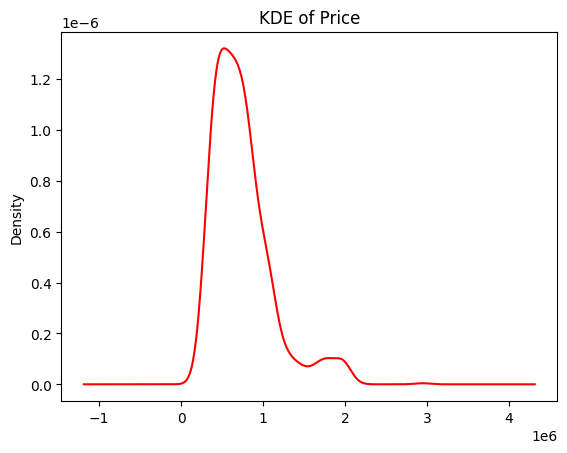

In [10]:
cars['Price'].plot.kde(color = 'red')
plt.title('KDE of Price')

This is all positive and right-skewed, so a log-transformation should be fine for this.

Text(0.5, 1.0, 'KDE of Mileage_Run')

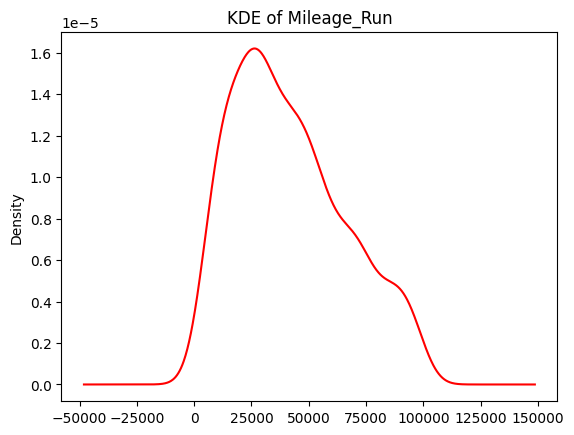

In [11]:
cars['Mileage_Run'].plot.kde(color = 'red')
plt.title('KDE of Mileage_Run')

This variable is also positive and right-skewed, so a log-transformation should also work just fine for this.

In [12]:
print(f'Original shape of cars dataframe: {cars.shape}')
price_low = cars['Price'].quantile(0.01) # outliers cutoff for too low
price_high = cars['Price'].quantile(0.99) # outliers cutoff for too high

cars = cars[cars['Price'].between(price_low, price_high)]
print(f'New shape of cars dataframe after removing outliers: {cars.shape}')

Original shape of cars dataframe: (976, 11)
New shape of cars dataframe after removing outliers: (956, 11)


In [13]:
cars['logged_Price'] = np.log(cars['Price']) # log transformation
cars['logged_Mileage_Run'] = np.log(cars['Mileage_Run'])

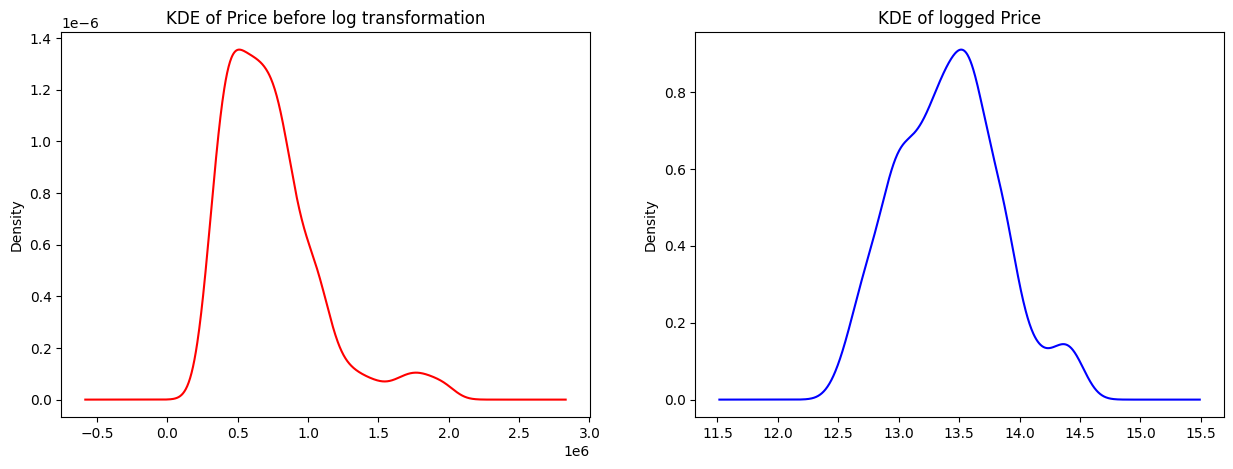

In [14]:
# Check distributions after log transformations
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

cars['Price'].plot.kde(ax = axes[0], color = 'red')
axes[0].set_title('KDE of Price before log transformation')

cars['logged_Price'].plot.kde(ax = axes[1], color = 'blue')
axes[1].set_title('KDE of logged Price')

plt.show()

In [15]:
cars['No_of_Owners'].unique()

<StringArray>
['1st', '2nd', '3rd']
Length: 3, dtype: str

In [16]:
# Change No_of_owners to numeric by taking the first number of the string

cars['No_of_Owners'] = cars['No_of_Owners'].apply(lambda x: 1 if x == '1st' else 2 if x == '2nd' else 3)
cars['No_of_Owners'].value_counts()


No_of_Owners
1    804
2    148
3      4
Name: count, dtype: int64

### Q2.2

count    9.560000e+02
mean     7.319100e+05
std      3.388222e+05
min      2.710000e+05
25%      4.827500e+05
50%      6.665000e+05
75%      8.772500e+05
max      1.978000e+06
Name: Price, dtype: float64


Text(0.5, 1.0, 'KDE of Price')

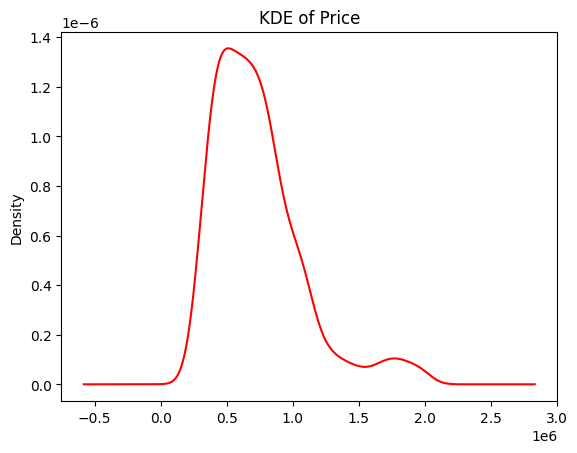

In [17]:
# Summarize the Price variable and create a kernel density plot.
print(cars['Price'].describe())
cars['Price'].plot.kde(color = 'red')
plt.title('KDE of Price')

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        5.0  4.908000e+05  256093.147116   273000.0   335000.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        303.0  6.947525e+05  277837.000404   273000.0   491000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  288.0  5.946146e+05  213253.690825   271000.0   416500.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

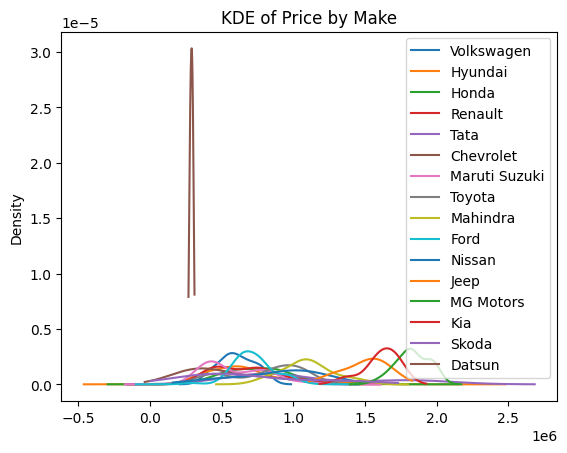

In [18]:
# Use .groupby() and .describe() to summarize prices by brand (Make).
print(cars.groupby('Make')['Price'].describe())

# # Make a grouped kernel density plot by Make. 
for make in cars['Make'].unique():
    subset = cars[cars['Make'] == make]
    subset['Price'].plot.kde(label = make)
plt.title('KDE of Price by Make')
plt.legend()
plt.show()

### Which car brands are the most expensive?
The most expensive car brands appear to be MG Motors, Kia, and Jeep.

### What do prices look like in general?
Prices in general look somewhat spread out across the range, but a bit skewed to the right with the exception of those more expensive brands.

### Q2.3

In [19]:
# Split the data into an 80% training set and a 20% testing set.
y2 = cars['logged_Price']

# get both numeric and categorical features
X_numeric = cars[['Make_Year', 'logged_Mileage_Run', 'No_of_Owners', 'Seating_Capacity']]
X_categorical = pd.get_dummies(cars[['Make', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'Color']], drop_first = True).astype(int)

# combine with concatenate for model with both
X_both = pd.concat([X_numeric, X_categorical], axis = 1)

# split the data 80/20
X2_train, X2_test, y2_train, y2_test = train_test_split(X_both, y2, test_size = 0.2, random_state = 100)

### Q2.4

In [20]:
# Numeric model
model_numeric = LinearRegression().fit(X2_train[X_numeric.columns], y2_train)
ynum_pred = model_numeric.predict(X2_test[X_numeric.columns])
print(f'R^2 value on train set for numeric only: {r2_score(y2_train, model_numeric.predict(X2_train[X_numeric.columns]))}')
print(f'RMSE value on train set for numeric only: {np.sqrt(mean_squared_error(y2_train, model_numeric.predict(X2_train[X_numeric.columns])))}')
print(f'R^2 value on test set for numeric only: {r2_score(y2_test, ynum_pred)}')
print(f'RMSE value on test set for numeric only: {np.sqrt(mean_squared_error(y2_test, ynum_pred))}')
print('\n')

# Categorical model
model_categorical = LinearRegression().fit(X2_train[X_categorical.columns], y2_train)
ycat_pred = model_categorical.predict(X2_test[X_categorical.columns])
print(f'R^2 value on test set for categorical only: {r2_score(y2_test, ycat_pred)}')
print(f'RMSE value on test set for categorical only: {np.sqrt(mean_squared_error(y2_test, ycat_pred))}')
print('\n')

# Combined model
model_combined = LinearRegression().fit(X2_train, y2_train)
yboth_pred = model_combined.predict(X2_test)
print(f'R^2 value on test set for combined model: {r2_score(y2_test, yboth_pred)}')
print(f'RMSE value on test set for combined model: {np.sqrt(mean_squared_error(y2_test, yboth_pred))}')

R^2 value on train set for numeric only: 0.4031554505951692
RMSE value on train set for numeric only: 0.32930114025639884
R^2 value on test set for numeric only: 0.36327973035341943
RMSE value on test set for numeric only: 0.34227944738222227


R^2 value on test set for categorical only: 0.6209812932509782
RMSE value on test set for categorical only: 0.26408078788629474


R^2 value on test set for combined model: 0.8131092194091312
RMSE value on test set for combined model: 0.18543872103376063


The joint model performs better by quite a bit. Its R^2 is 0.813, compared to about half that in the numeric only model and only 0.62 in the categorical only model. The RMSE is also the lowest in the joint model at only 0.185, while the numeric model has 0.342 on its test set, and the categorical model has 0.264 on its test set, clearly setting apart the joint model as the best option by a decent margin.

### Q2.5

In [21]:
# Use PolynomialFeatures to expand set of numerical variables used
for degree in range(2, 6):
    polynomial = PolynomialFeatures(degree = degree, include_bias = False)
    X_numeric_expanded_train = polynomial.fit_transform(X2_train[X_numeric.columns])
    X_numeric_expanded_test = polynomial.transform(X2_test[X_numeric.columns])

    poly_model = LinearRegression().fit(X_numeric_expanded_train, y2_train)
    ynum_poly_pred = poly_model.predict(X_numeric_expanded_test)

    print(f'R^2 value on test set on expanded numeric set with degree {degree}: {r2_score(y2_test, ynum_poly_pred)}')
    print(f'RMSE value on test set on expanded numeric set with degree {degree}: {np.sqrt(mean_squared_error(y2_test, ynum_poly_pred))}')
    print('\n')

R^2 value on test set on expanded numeric set with degree 2: 0.39633720081479684
RMSE value on test set on expanded numeric set with degree 2: 0.3332757319746484


R^2 value on test set on expanded numeric set with degree 3: -2.7840529703533576
RMSE value on test set on expanded numeric set with degree 3: 0.8344207356298191


R^2 value on test set on expanded numeric set with degree 4: -3.787090531807917
RMSE value on test set on expanded numeric set with degree 4: 0.9385173479767042


R^2 value on test set on expanded numeric set with degree 5: -3.81174372556979
RMSE value on test set on expanded numeric set with degree 5: 0.9409308951258147




#### As degree of expansion increases, how do R^2 and RMSE on the test set change?

As degree of expansion increases, R^2 increases slightly at first, but then starts to rapidly decrease into the negatives and keep going from there. RMSE decreases slightly at first, but then jumps up as R^2 becomes negative. This is very slight improvement at first, but then becomes quite bad after we reach degree 3 in terms of R^2. The model is definitely becoming overfit at this point.

#### At what point does R^2 go negative on the test set?

R^2 goes negative at degree 3 on the test set.

#### For your best model with expanded features, what is the R^2 and RMSE?
The best model with expanded features is degree 2, and its R^2 is 0.396 and its RMSE is 0.333.

#### How does it compare to your best model from part 4?
This is worse than the best model from part 4 because the joint model from part 4 had R^2 of 0.813 and RMSE of 0.185. This joint model is significantly better than the best model from part 5 as it has less than half the R^2 value and almost double the RMSE.

### Q2.6

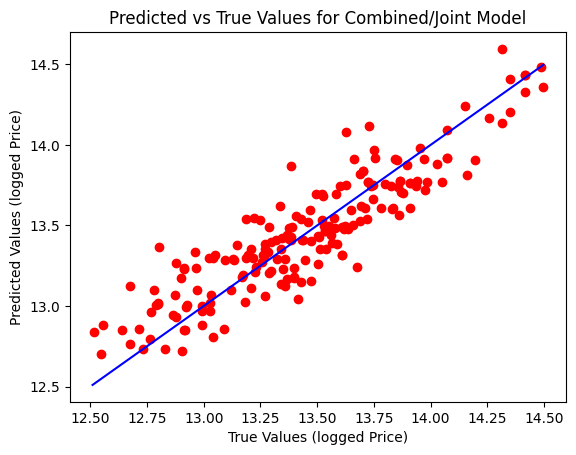

In [22]:
# For your best model so far, determine the predicted values for the test data and plot them against the true values. 
plt.scatter(y2_test, yboth_pred, color = 'red')
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], color = 'blue') # add a line for predictions
plt.title('Predicted vs True Values for Combined/Joint Model')
plt.xlabel('True Values (logged Price)')
plt.ylabel('Predicted Values (logged Price)')
plt.show()

#### Do the predicted values and true values roughly line up along the diagonal, or not? 
The predicted values and true values roughly line up along the diagonal. It's obviously not perfect since it's a prediction model, but it definitely looks like a quite good prediction model.

#### Compute the residuals/errors for the test data and create a kernel density plot. 

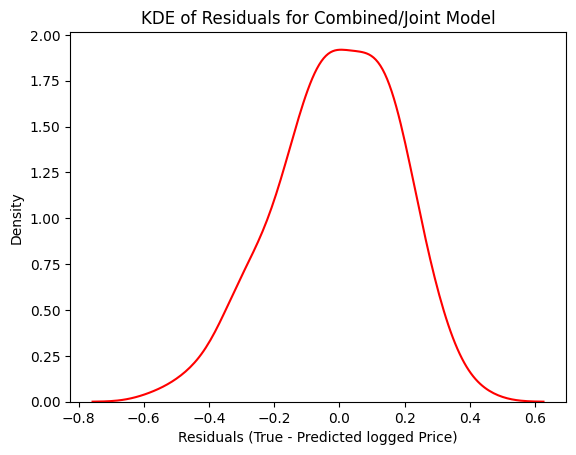

Residuals mean: -0.007358994393782912
Residuals standard deviation: 0.18577707149973882


In [23]:
# Residuals for test data
residuals = y2_test - yboth_pred
sns.kdeplot(residuals, color = 'red')
plt.title('KDE of Residuals for Combined/Joint Model')
plt.xlabel('Residuals (True - Predicted logged Price)')
plt.show()

print(f'Residuals mean: {residuals.mean()}')
print(f'Residuals standard deviation: {residuals.std()}')

#### Do the residuals look roughly bell-shaped around zero?
Yes, the residuals are centered around -0.007, which is very close to 0, and seems roughly normal or bell-shaped.

#### Evaluate the strengths and weaknesses of your model.
Strengths include the prediction power as R^2 is very high, so predictions on outside data should work quite well. It also has corrected for skew as price has been logged.

Weaknesses include RMSE of 0.185, which isn't super great, but it's not bad either. This is still a somewhat rough outline of a more improved model, but for a starter model with limited conditions and such, it's pretty good. It may have trouble making predictions on cars with different combinations like a more valuable car with higher mileage versus a cheaper car with higher mileage since they are valued VERY differently in the real world.

# Question 3

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

### Q3.1

In [24]:
dbd = pd.read_csv('DBDData.csv') # this is my own personal dataset I collected on matches I've played in a video game called Dead by Daylight
dbd.head()

,Survivor Gender,Steam Player,Anonymous Mode,Prestige,Item,Powerful Add-ons,Exhaustion Perk,Chase Perks,Decisive Strike,Unbreakable,Off the Record,Adrenaline,Map Type,Map Area,Survivor BP,Killer BP,Result
0,M,No,No,26,Medkit,No,NaN,0,No,No,No,No,Outdoor,9984,21706,25250,Escape
1,M,No,No,11,Medkit,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,16049,25250,Dead
2,F,No,No,11,Toolbox,No,Dead Hard,1,No,No,No,No,Outdoor,9984,15402,25250,Dead
3,F,No,No,5,Toolbox,No,Lithe,0,No,Yes,No,Yes,Outdoor,9984,7048,25250,Dead
4,F,Yes,No,54,Toolbox,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,15996,25700,Dead


### Q3.2

In [25]:
# Repace NaN values with the string "None", as I put the word None to indicate that this category of thing was not brought by the player, they're not actually missing values (slight oversight on my part when collecting the data)

dbd['Item'] = dbd['Item'].fillna('None')
dbd['Exhaustion Perk'] = dbd['Exhaustion Perk'].fillna('None')
dbd.head()

,Survivor Gender,Steam Player,Anonymous Mode,Prestige,Item,Powerful Add-ons,Exhaustion Perk,Chase Perks,Decisive Strike,Unbreakable,Off the Record,Adrenaline,Map Type,Map Area,Survivor BP,Killer BP,Result
0,M,No,No,26,Medkit,No,None,0,No,No,No,No,Outdoor,9984,21706,25250,Escape
1,M,No,No,11,Medkit,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,16049,25250,Dead
2,F,No,No,11,Toolbox,No,Dead Hard,1,No,No,No,No,Outdoor,9984,15402,25250,Dead
3,F,No,No,5,Toolbox,No,Lithe,0,No,Yes,No,Yes,Outdoor,9984,7048,25250,Dead
4,F,Yes,No,54,Toolbox,No,Sprint Burst,0,No,No,No,No,Outdoor,9984,15996,25700,Dead


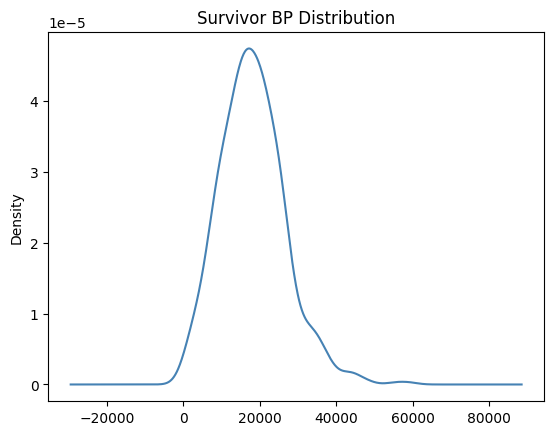

In [26]:
# Distribution of our y variable (check for any major skew)
dbd['Survivor BP'].plot.kde(color='steelblue')
plt.title('Survivor BP Distribution')
plt.show()

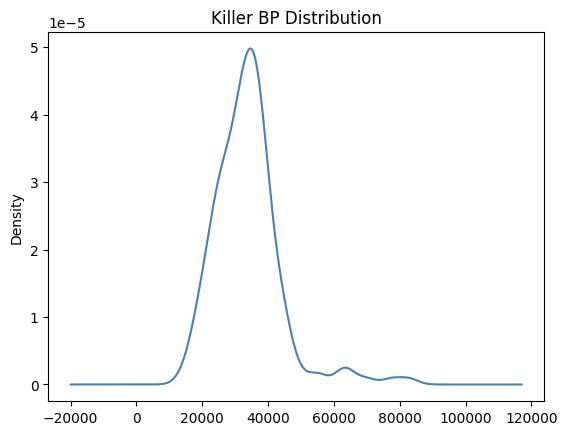

In [27]:
# Could be heavily correlated, but I'm not completely sure
dbd['Killer BP'].plot.kde(color='steelblue')
plt.title('Killer BP Distribution')
plt.show()

This appears skewed right and maybe technically multimodal with the other spikes on the right? This could indicate how there are different types/categories of matches and how they go. Probably not quite worth logging though.

In [28]:
# Average BP outcomes per result
dbd.groupby('Result')['Survivor BP'].mean()

Result
Dead      16399.705882
Escape    27950.196078
Name: Survivor BP, dtype: float64

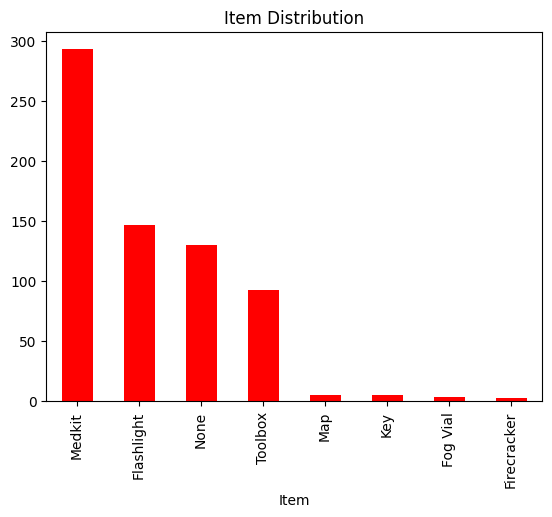

In [29]:
dbd['Item'].value_counts().plot.bar(color = 'red')
plt.title('Item Distribution')
plt.show()

Heavy weight towards medkits, flashlights, and toolboxes (which makes sense from my personal experience, those are easily the easiest and strongest items to use).

### Q3.3

In [30]:
# Set X and y for the model
ydbd = dbd['Survivor BP'] # since we're doing regression, it's best to predict a numeric variable (in this case, the points each player got at the end of the round)
Xdbd = pd.get_dummies(dbd.drop(columns = 'Survivor BP'), drop_first = True).astype(int)

# Split the sample 80/20 into train and test sets
Xdbd_train, Xdbd_test, ydbd_train, ydbd_test = train_test_split(Xdbd, ydbd, test_size = 0.2, random_state = 100)
print(f'Train size: {Xdbd_train.shape}')
print(f'Test size: {Xdbd_test.shape}')

Train size: (544, 30)
Test size: (136, 30)


### Q3.4

In [31]:
# Model 1 (only numeric features)
numeric_cols_dbd = ['Prestige', 'Chase Perks', 'Map Area', 'Killer BP'] # there are only 4 actual numeric columns in the dataset, the rest are categorical

model_dbd_numeric = LinearRegression().fit(Xdbd_train[numeric_cols_dbd], ydbd_train)
ydbd_numeric_pred = model_dbd_numeric.predict(Xdbd_test[numeric_cols_dbd])

print(f'R^2 value on test set for numeric model: {r2_score(ydbd_test, ydbd_numeric_pred)}')
print(f'RMSE value on test set for numeric model: {np.sqrt(mean_squared_error(ydbd_test, ydbd_numeric_pred))}')

R^2 value on test set for numeric model: 0.0552774578270262
RMSE value on test set for numeric model: 7619.365467254273


In [32]:
# Model 2 (only categorical features)
categorical_cols_dbd = [column for column in Xdbd_train.columns if column not in numeric_cols_dbd]

model_dbd_cat = LinearRegression().fit(Xdbd_train[categorical_cols_dbd], ydbd_train)
ydbd_cat_pred = model_dbd_cat.predict(Xdbd_test[categorical_cols_dbd])

print(f'R^2 value on test set for categorical model: {r2_score(ydbd_test, ydbd_cat_pred)}')
print(f'RMSE value on test set for categorical model: {np.sqrt(mean_squared_error(ydbd_test, ydbd_cat_pred))}')

R^2 value on test set for categorical model: 0.17196208223196752
RMSE value on test set for categorical model: 7133.321175436845


In [33]:
# Model 3 (all features)
model_dbd_all =  LinearRegression().fit(Xdbd_train, ydbd_train)
ydbd_all_pred = model_dbd_all.predict(Xdbd_test)

print(f'R^2 value on test set for combined model: {r2_score(ydbd_test, ydbd_all_pred)}')
print(f'RMSE value on test set for combined model: {np.sqrt(mean_squared_error(ydbd_test, ydbd_all_pred))}')

R^2 value on test set for combined model: 0.36513021765116094
RMSE value on test set for combined model: 6246.100883684851


### Q3.5
The model that performed best is the combined model using all the features available (numeric and categorical). It had an R^2 value of 0.365 and an RMSE of 6246.1. For context on the RMSE, the amount of points a survivor gets ranges from 0 to about 40,000. This still isn't great since that's still quite a bit of wiggle room within that range, but that's part of why it's such a large number. The combined model performed best because the points and map info (numeric variables) likely aren't enough information on their own to predict the points a player gets, and the categorical variables do a better job of predicting, but are still better when complemented with map info and such. This is likely because knowing perks and items are good indicators of things like stronger players at times, but without the other info like killer points and map size, it's not as good for predicting because those factors are still quite influential.

### Q3.6
I learned that this dataset probably needs a different model other than regression or to pick a different y variable for this set like the result category (although that would require a different model as well since it's then classification). I also learned that it's probably not very easy to predict just based off the visible factors a player exhibits how well they will do and how many points they will get because there are so many more factors than just those we can see, especially skill and experience. The best model only had an R^2 value of 0.365, which is still not great. It's better than the other models I made for the dataset, but mediocre nonetheless. This difficulty does make sense though since a match contains much more than just those stats that are visible on the leaderboard at the end of a match, especially for points since points come largely from actions within the match itself and the result contributing a few thousand to the total at the end.

I was not super surprised to learn that the numeric variables are not as good for prediction as the categorical variables because the heavy hitters are mostly in the categorical side (perks brought, map type, and item brought). I might be able to improve the model by getting a more diverse dataset and also a larger dataset, but I'm still not super confident in the ability for a regression model to obtain a good result on its own (as it may need a different model either to replace it or to be paired with it).

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [34]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

NameError: name 'X' is not defined

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
